# Harmonizer (dual-excitation PAM fluorometer) — Leaf response to harmonic actinic light (Figures 10 & 11)

**Paper:** V. Jokinen *et al.*, "A novel dual-excitation pulse-amplitude-modulation fluorometer for
investigating photosynthesis of plants", bioRxiv 2024.04.18.589113v1
(https://doi.org/10.1101/2024.04.18.589113).

**Author data/code (CC BY, KORDS at King's College London):**
- Article [25599564](https://doi.org/10.18742/25599564.v1): `Figures_10_11_pointsettia.zip` —
  processed data `processedData.mat`, the author's MATLAB script `makeGraphs.m`, and the published
  reference figures `intensity.eps` / `mixFreq1.eps`.
- Article [25602054](https://doi.org/10.18742/25602054.v1): Raspberry Pi/Arduino source (not needed here).

## Scope and execution status
- **Partial demonstration, ADAPTED PYTHON DEMONSTRATION.** We regenerate the paper's Figure 10
  (fluorescence-yield response of a poinsettia leaf to harmonic actinic light at three irradiances,
  with phase delays Δφmax, Δφmin and peak-to-peak amplitude A_Pk-Pk) and Figure 11 (response to two
  simultaneously modulated lights vs the sum of the individual responses — the paper's key
  non-additivity result) from the authors' own processed data.
- **AI-assisted translation from MATLAB.** The author script `makeGraphs.m` cannot run in GNU Octave
  (it uses ~566 MATLAB handle dot-property accesses unsupported in Octave), so this notebook
  re-implements its numerical core in Python from the same `processedData.mat`. The authors did not
  provide this Python implementation; executed checks are validated against the authors' reference
  figures included in the archive, but untested behavior is not guaranteed.
- 実行環境は CPU のみ。所要時間の目安は全体で 10〜15 分（703 MB のダウンロードを含む）。

**日本語要約:** 本ノートブックは、Harmonizer（2つの正弦波変調青色光 + 約60 kHz パルス測定光を持つ
自作 PAM 蛍光計）の公開処理済みデータ `processedData.mat` から、論文 Fig. 10（葉の蛍光収率応答と
位相遅れ・振幅）および Fig. 11（2光同時変調の応答が個別応答の和にならない＝非線形性）を再現します。
著者の MATLAB スクリプト `makeGraphs.m` の数値処理核心を Python へ翻訳した「改変デモ」です。
著者の参考図（EPS, CC BY）を併示して検証します。

## Runtime selection
**Select Runtime > Change runtime type > CPU (standard).** No GPU is used or useful: the workload is
plotting and peak detection on ~10⁴–10⁵-point time series. A GPU would not make this analysis more
faithful or faster in any meaningful way.
**GPU は不要です。CPU ランタイムを選択してください。** All downloads and computation happen inside
this Colab VM; nothing runs on any other host.

In [ ]:
import platform, os, sys
print("Python:", sys.version.split()[0])
print("Machine:", platform.machine(), "| CPUs:", os.cpu_count())
try:
    import psutil
    print(f"RAM: {psutil.virtual_memory().total/2**30:.1f} GiB")
except ImportError:
    pass
print("Expected total download: 703 MB (one-time)")

Python: 3.13.15
Machine: x86_64 | CPUs: 2
RAM: 12.7 GiB
Expected total download: 703 MB (one-time)


## Environment setup
The analysis uses `h5py` (to read the authors' MATLAB v7.3/HDF5 `processedData.mat` — GNU Octave and
`scipy.io.loadmat` cannot read this format), `scipy` (peak detection), `numpy`/`pandas`/`matplotlib`
(analysis, tables, figures), and `ghostscript` (to render the authors' reference EPS figures for
comparison). Colab preinstalls most of these; we ensure the exact set and print versions.
**必要なライブラリを整備します**（`h5py` は MATLAB v7.3 形式の読み取りに必須）。

In [ ]:
import subprocess
subprocess.run("apt-get update -qq && apt-get install -y -qq ghostscript", shell=True, check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-input",
                "h5py", "scipy", "pandas", "matplotlib"], check=True)
import h5py, scipy, numpy, pandas, matplotlib
for m in (h5py, scipy, numpy, pandas, matplotlib):
    print(m.__name__, m.__version__)

h5py 3.16.0
scipy 1.16.3
numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0


## Input acquisition (inside Colab only)
Download the authors' archive `Figures_10_11_pointsettia.zip` from the KORDS/Figshare record
[25599564](https://doi.org/10.18742/25599564.v1) (file id 45641880, CC BY). We first try the full
703 MB download with MD5 verification (`b99ee2ab7b574aac5a968c1878a0a808` from the record
metadata). If the provider throttles that large transfer, we fall back to a selective HTTP-Range
extraction of only the three required members (`processedData.mat`, `intensity.eps`,
`mixFreq1.eps`) from the zip's central directory, each verified by its recorded ZIP CRC32.
**まず 703 MB の完全ダウンロードと MD5 検証を試み、失敗した場合は HTTP Range による必要ファイル
のみの部分取得（CRC32 検証付き）にフォールバックします。** The same bytes are never fetched or
processed outside this VM.

In [ ]:
import hashlib, pathlib, struct, subprocess, time, zlib, urllib.request

URLS = ["https://ndownloader.figshare.com/files/45641880",
        "https://kcl.figshare.com/ndownloader/files/45641880"]  # record + institutional mirror
EXPECTED_MD5 = "b99ee2ab7b574aac5a968c1878a0a808"
EXPECTED_SIZE = 703320811
ARCH = "/content/f1011/Figures_10_11_pointsettia"
dest = pathlib.Path("/content/Figures_10_11_pointsettia.zip")
NEEDED = ["Figures_10_11_pointsettia/processedData.mat",
          "Figures_10_11_pointsettia/intensity.eps",
          "Figures_10_11_pointsettia/mixFreq1.eps"]

def range_get(url, start, end):
    req = urllib.request.Request(url, headers={"Range": f"bytes={start}-{end}"})
    with urllib.request.urlopen(req, timeout=180) as r:
        return r.status, r.headers.get("Content-Range"), r.read()

def selective_fetch(url, member, out_path):
    t0 = time.time()
    _, cr, _ = range_get(url, 0, 0)
    total = int(cr.split("/")[-1])
    tail = range_get(url, total - 65536, total - 1)[2]
    eocd = tail.rfind(b"PK\x05\x06"); assert eocd >= 0, "no EOCD"
    _, _, _, _, _, cdsize, cdoff, _ = struct.unpack("<IHHHHIIH", tail[eocd:eocd + 22])
    cd = range_get(url, cdoff, cdoff + cdsize - 1)[2]
    pos, found = 0, False
    while pos < len(cd) and cd[pos:pos + 4] == b"PK\x01\x02":
        (ver, vneed, flags, method, mt, md, crc, csize, usize, nlen, elen, clen,
         dstart, iattr, eattr, lho) = struct.unpack("<HHHHHHIIIHHHHHII", cd[pos + 4:pos + 46])
        name = cd[pos + 46:pos + 46 + nlen].decode()
        pos += 46 + nlen + elen + clen
        if name == member: found = True; break
    assert found, f"{member} not in central directory"
    lh = range_get(url, lho, lho + 29)[2]
    nlen2, elen2 = struct.unpack("<HH", lh[26:30])
    data = range_get(url, lho + 30 + nlen2 + elen2, lho + 30 + nlen2 + elen2 + csize - 1)[2]
    assert zlib.crc32(data) & 0xFFFFFFFF == crc, f"CRC32 mismatch for {member}"
    raw = zlib.decompress(data, -15) if method == 8 else data
    out_path.write_bytes(raw)
    print(f"selectively fetched {member}: {len(raw)} bytes (CRC32 OK, {time.time()-t0:.0f} s)")

t0 = time.time()
FULL = False
last_err = None
def try_full(url):
    subprocess.run(["curl", "-L", "--fail", "--retry", "5", "--retry-all-errors",
                    "--retry-delay", "15", "--connect-timeout", "30", "-C", "-",
                    "-o", str(dest), url], check=True)
    h = hashlib.md5()
    with open(dest, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 22), b""):
            h.update(chunk)
    assert h.hexdigest() == EXPECTED_MD5, f"md5 mismatch: {h.hexdigest()}"

for u in URLS:
    try:
        if not (dest.exists() and dest.stat().st_size == EXPECTED_SIZE):
            dest.unlink(missing_ok=True)
            try_full(u)
        else:
            try_full(u)  # verify md5 of an existing file too
        print(f"full archive verified: {dest.stat().st_size} bytes in {time.time()-t0:.0f} s ({u})")
        FULL = True
        break
    except Exception as e:
        last_err = e
        print(f"full download failed for {u}: {e}")
if not FULL:
    print(f"all full downloads failed ({last_err}); using selective HTTP-Range extraction")
    ARCH_DIR = pathlib.Path(ARCH); ARCH_DIR.mkdir(parents=True, exist_ok=True)
    for m in NEEDED:
        ok = False
        for u in URLS:
            try:
                selective_fetch(u, m, ARCH_DIR / pathlib.Path(m).name); ok = True; break
            except Exception as e2:
                print(f"selective fetch of {m} failed for {u}: {e2}")
        assert ok, f"could not fetch {m} from any route"
print("FULL =", FULL)

full archive verified: 703320811 bytes in 26 s (https://ndownloader.figshare.com/files/45641880)
FULL = True


## Extract and inspect the archive
Extract under `/content` (or use the selectively fetched members) and list the author's `.m`
scripts and reference `.eps` figures. The reference figures are the authors' published outputs
(CC BY) — we keep them clearly labeled as author source material for later comparison. They are
not our results. **アーカイブを展開し、著者のスクリプトと参考図を確認します。**

In [ ]:
import zipfile
if FULL:
    zipfile.ZipFile(dest).extractall("/content/f1011")
    names = zipfile.ZipFile(dest).namelist()
else:
    names = sorted(str(p.relative_to("/content/f1011"))
                   for p in pathlib.Path("/content/f1011").rglob("*") if p.is_file())
print("entries:", len(names))
for n in sorted(names):
    if n.endswith((".m", ".mat", ".eps")):
        print(" ", n, pathlib.Path("/content/f1011", n).stat().st_size, "bytes")

entries: 51
  Figures_10_11_pointsettia/2023_12_16-19_39_04---poinsettia-afp45----a45-o3-p0_0.0-f0.0111_0.011038-A0-O3-P0_0.0-F0.0111_0.011038-m10-s720.eps 1476697 bytes
  Figures_10_11_pointsettia/2023_12_16-20_06_14---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0111_0.011038-m10-s720.eps 1477152 bytes
  Figures_10_11_pointsettia/2023_12_16-20_19_54---poinsettia-afp----a30-o3-p0_0.0-f0.0111_0.011038-A0-O0-P0_0.0-F0.0167_0.016557-m10-s720.eps 1477463 bytes
  Figures_10_11_pointsettia/2023_12_16-20_33_35---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0125_0.012142-m10-s720.eps 790681 bytes
  Figures_10_11_pointsettia/2023_12_16-20_47_15---poinsettia-afp----a30-o3-p0_0.0-f0.0111_0.011038-A0-O0-P0_0.0-F0.0167_0.016557-m10-s720.eps 1479631 bytes
  Figures_10_11_pointsettia/2023_12_16-21_00_46---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011536-A32-O3-P0_0.0-F0.0098_0.0096137-m10-s720.eps 1542132 bytes
  Figures_10_11_pointsettia/2023_12_16-21_14

## Load the processed data (v7.3 HDF5 mat)
`processedData.mat` is a MATLAB v7.3 file: each experiment is one element of a 1×21 struct array
`fnames` whose fields (`a`, `A`, `f`, `F`, `Time`, `time`, `measurement`, `measurementNI`,
`model`, `modelReal`, `s0H`, `s1H`, ...) are stored as HDF5 object references. We dereference them
with `h5py` into plain dicts — exactly the data the author's `load('processedData.mat')` would
provide to `makeGraphs.m` (makeGraphs.m line 2).
**v7.3 形式の mat を h5py で読み込み、実験テーブルを表示します**（a/A: 2つの青色光の振幅設定、
f/F: 変調周波数 [Hz]、measurementNI: 蛍光収率、model/modelReal: 正弦波モデル）。

In [ ]:
import h5py
import numpy as np

hf_mat = h5py.File(f"{ARCH}/processedData.mat", "r")
refs = hf_mat["#refs#"]
field_names = list(hf_mat["fnames"].keys())
n_exp = hf_mat["fnames"]["a"].shape[1]

def deref(v):
    out = np.empty(v.shape, dtype=object)
    for idx, ref in np.ndenumerate(v):
        out[idx] = refs[ref]
    return out

def to_val(ds):
    a = ds[()]
    if a.dtype == np.uint16:                      # MATLAB char -> str
        return "".join(chr(int(x)) for x in np.atleast_1d(a).ravel())
    if a.dtype == np.uint8:                       # MATLAB logical
        return bool(a.ravel()[0]) if a.size == 1 else a.astype(bool)
    return a

cols = {k: deref(hf_mat["fnames"][k][()]) for k in field_names}
recs = []
for i in range(n_exp):
    r = {k: to_val(cols[k][0, i]) for k in field_names}
    for key in ("Time", "time", "measurement", "measurementNI", "model", "modelReal"):
        r[key] = np.asarray(r[key]).ravel()
    recs.append(r)
print(f"loaded {len(recs)} experiments; fields: {sorted(field_names)}")

loaded 21 experiments; fields: ['A', 'F', 'Time', 'a', 'bytes', 'date', 'datenum', 'f', 'folder', 'isdir', 'measurement', 'measurementNI', 'model', 'model1cos0H', 'model1cos1H', 'modelReal', 'name', 's0H', 's1H', 'time']


### Experiment inventory
Show one concise table of all 21 experiments: measurement date/name, actinic amplitudes `a` (light 1)
and `A` (light 2), modulation frequencies `f` and `F` [Hz], and the number of decimated
fluorescence-yield samples. This is directly observed content from the authors' file — not
interpretation. In the filename convention, lower-case parameters belong to light 1 and upper-case
to light 2 (rpi/main/main.py writes this name when recording).
**全 21 実験の一覧を表示します。**

In [ ]:
import pandas as pd
inv = pd.DataFrame([{
    "name": r["name"], "date": r["date"],
    "a": float(np.asarray(r["a"]).ravel()[0]),
    "A": float(np.asarray(r["A"]).ravel()[0]),
    "f [Hz]": float(np.asarray(r["f"]).ravel()[0]),
    "F [Hz]": float(np.asarray(r["F"]).ravel()[0]),
    "n FY pts": len(r["measurementNI"]),
} for r in recs])
print(inv.to_string(index=False))

                                                                                                                 name                 date    a    A   f [Hz]   F [Hz]  n FY pts
  2023_12_16-19_39_04---poinsettia-afp45----a45-o3-p0_0.0-f0.0111_0.011038-A0-O3-P0_0.0-F0.0111_0.011038-m10-s720.bin 17-Dec-2023 08:28:40 45.0  0.0 0.011038 0.011038     17202
  2023_12_16-20_06_14---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0111_0.011038-m10-s720.bin 17-Dec-2023 08:30:51 30.0 32.0 0.011038 0.011038     17202
    2023_12_16-20_19_54---poinsettia-afp----a30-o3-p0_0.0-f0.0111_0.011038-A0-O0-P0_0.0-F0.0167_0.016557-m10-s720.bin 17-Dec-2023 08:31:49 30.0  0.0 0.011038 0.016557     17202
  2023_12_16-20_33_35---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0125_0.012142-m10-s720.bin 17-Dec-2023 08:32:42 30.0 32.0 0.011038 0.012142     18928
    2023_12_16-20_47_15---poinsettia-afp----a30-o3-p0_0.0-f0.0111_0.011038-A0-O0-P0_0.0-F0.0167_0.016557-m10-s720.b

## Figure 10 — leaf response at three irradiances
**Method mapping (makeGraphs.m → Python):** selection `oneFreqIn = (xor(a~=0, A~=0)) | (f==F)`
(line 11), most common frequency `mostCfreq = mode(f)` (line 14), sort by total amplitude
`a+A` descending (lines 24–25) and keep three levels `[1 2 4]` (line 27). For each level we plot the
decimated fluorescence yield `measurementNI` vs `time` (left axis, RU) and the actinic model
`modelReal` scaled to PPFD (`A*6.08 − 30.8`, `a*6.12 − 12.4`, average if both lights on — lines
33–35, 109–119) on the right axis. Peaks of `measurementNI` and `model` are found with
`MinPeakProminence = rms*sqrt(2)/4` and `MinPeakDistance = 1/(max(f,F)*6)/dt` (lines 125–131,
scipy `find_peaks`). Phase delay Δφmax = (nearest later model-peak time − data-peak time) ×
`mostCfreq` × 2π (lines 296–300); Δφmin analogously; A_Pk-Pk = mNI[imax] − mNI[imax+M]
(lines 303–306). Side panels show these per period, as in the author's figure.
**Fig. 10 を再現します**（上:高・中:中・下:低照度、左軸 FY [RU]、右軸 actinic PPFD）。

In [ ]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib as mpl

def amp_a(i):  return float(np.asarray(recs[i]["a"]).ravel()[0])
def amp_A(i):  return float(np.asarray(recs[i]["A"]).ravel()[0])
def freq_f(i): return float(np.asarray(recs[i]["f"]).ravel()[0])
def freq_F(i): return float(np.asarray(recs[i]["F"]).ravel()[0])

a_arr = np.array([amp_a(i) for i in range(n_exp)])
A_arr = np.array([amp_A(i) for i in range(n_exp)])
f_arr = np.array([freq_f(i) for i in range(n_exp)])
F_arr = np.array([freq_F(i) for i in range(n_exp)])

oneFreqIn = np.logical_xor(a_arr != 0, A_arr != 0) | (f_arr == F_arr)
vals, counts = np.unique(f_arr[oneFreqIn], return_counts=True)
mostCfreq = vals[counts.argmax()]
cand = [i for i in range(n_exp) if oneFreqIn[i] and (f_arr[i] == mostCfreq or F_arr[i] == mostCfreq)]
cand.sort(key=lambda i: a_arr[i] + A_arr[i], reverse=True)
mostCin = [cand[0], cand[1], cand[3]]          # author picks [1 2 4] (1-based)
print("mostCfreq =", mostCfreq, "Hz; selected experiments:", [inv["name"][i] for i in mostCin])

mostCfreq = 0.011038 Hz; selected experiments: ['2023_12_16-20_06_14---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0111_0.011038-m10-s720.bin', '2023_12_16-19_39_04---poinsettia-afp45----a45-o3-p0_0.0-f0.0111_0.011038-A0-O3-P0_0.0-F0.0111_0.011038-m10-s720.bin', '2023_12_16-20_19_54---poinsettia-afp----a30-o3-p0_0.0-f0.0111_0.011038-A0-O0-P0_0.0-F0.0167_0.016557-m10-s720.bin']


### Detect peaks, phase delays and amplitudes (makeGraphs.m lines 125–306)
Apply the author's exact peak criteria to each selected experiment and compute Δφmax, Δφmin and
A_Pk-Pk. Negative time differences (a model peak before the data peak) are discarded as NaN, and the
nearest later model peak is used, exactly as `min(maxTdiff, [], 2)` does.
**著者の基準（prominence・距離）でピーク検出し、位相遅れと A_Pk-Pk を計算します。**

In [ ]:
def analyze(i):
    r = recs[i]
    Time, time = r["Time"], r["time"]
    mNI, model = r["measurementNI"], r["model"]
    ym = mNI.mean()                                  # makeGraphs.m line 126
    yr = np.sqrt(np.mean((mNI - ym) ** 2)) * np.sqrt(2)   # line 128
    dt = Time[1] - Time[0]                           # line 130
    dist = 1 / (max(freq_f(i), freq_F(i)) * 6) / dt  # line 130
    inMaxD, _ = find_peaks(mNI, prominence=yr / 4, distance=dist)
    inMinD, _ = find_peaks(-mNI, prominence=yr / 4, distance=dist)
    inMaxM, _ = find_peaks(model, prominence=yr / 4, distance=dist)
    inMinM, _ = find_peaks(-model, prominence=yr / 4, distance=dist)
    tDmax = time[inMaxD]
    maxTdiff = Time[inMaxM][None, :] - tDmax[:, None]
    maxTdiff[maxTdiff < 0] = np.nan
    maxPdiff = np.nanmin(maxTdiff, axis=1) * mostCfreq    # line 301
    minTdiff = Time[inMinM][None, :] - time[inMinD][:, None]
    minTdiff[minTdiff < 0] = np.nan
    minPdiff = np.nanmin(minTdiff, axis=1) * mostCfreq    # line 313
    idx = (inMinD[None, :] - inMaxD[:, None]).astype(float)
    idx[idx < 0] = np.nan
    M = np.nanmin(idx, axis=1)
    # Deviation note: the author indexes directly and assumes every maximum has a
    # following minimum; we drop (rare) maxima without one so the translation is robust.
    ok = np.isfinite(M)
    ampDiff = mNI[inMaxD[ok]] - mNI[inMaxD[ok] + M[ok].astype(int)]
    return dict(inMaxD=inMaxD, inMinD=inMinD, inMaxM=inMaxM, inMinM=inMinM,
                maxPdiff=maxPdiff, minPdiff=minPdiff, ampDiff=ampDiff, yr=yr)

analyses = {i: analyze(i) for i in mostCin}
for i in mostCin:
    d = analyses[i]
    print(f"{inv['name'][i][:24]}... level a+A={amp_a(i)+amp_A(i):.0f}: "
          f"dphi_max={np.nanmean(d['maxPdiff'])*2*np.pi:.3f}+/-{np.nanstd(d['maxPdiff'])*2*np.pi:.3f} rad, "
          f"dphi_min={np.nanmean(d['minPdiff'])*2*np.pi:.3f}+/-{np.nanstd(d['minPdiff'])*2*np.pi:.3f} rad, "
          f"A_PkPk={d['ampDiff'].mean():.2f}+/-{d['ampDiff'].std():.2f} RU "
          f"(unmatched data peaks: {int(np.isnan(d['maxPdiff']).sum())})")

2023_12_16-20_06_14---po... level a+A=62: dphi_max=1.586+/-0.016 rad, dphi_min=1.413+/-0.045 rad, A_PkPk=88.59+/-0.70 RU (unmatched data peaks: 0)
2023_12_16-19_39_04---po... level a+A=45: dphi_max=1.501+/-0.013 rad, dphi_min=1.467+/-0.042 rad, A_PkPk=88.14+/-0.84 RU (unmatched data peaks: 0)
2023_12_16-20_19_54---po... level a+A=30: dphi_max=1.184+/-0.008 rad, dphi_min=1.818+/-0.038 rad, A_PkPk=68.87+/-0.59 RU (unmatched data peaks: 0)


### Render the Figure 10 analogue and save it as PNG
Three main rows (fluorescence yield with detected peaks marked, actinic PPFD model on the twin
axis) and three side panels (Δφmax, Δφmin, A_Pk-Pk per period), mirroring the author's layout.
The figure is saved to `/content/fig10_intensity.png` and displayed; it is our adapted result, not
the author's figure.
**Fig. 10 相当図を作成・保存します**（著者参考図とは意図的に描画が異なります）。

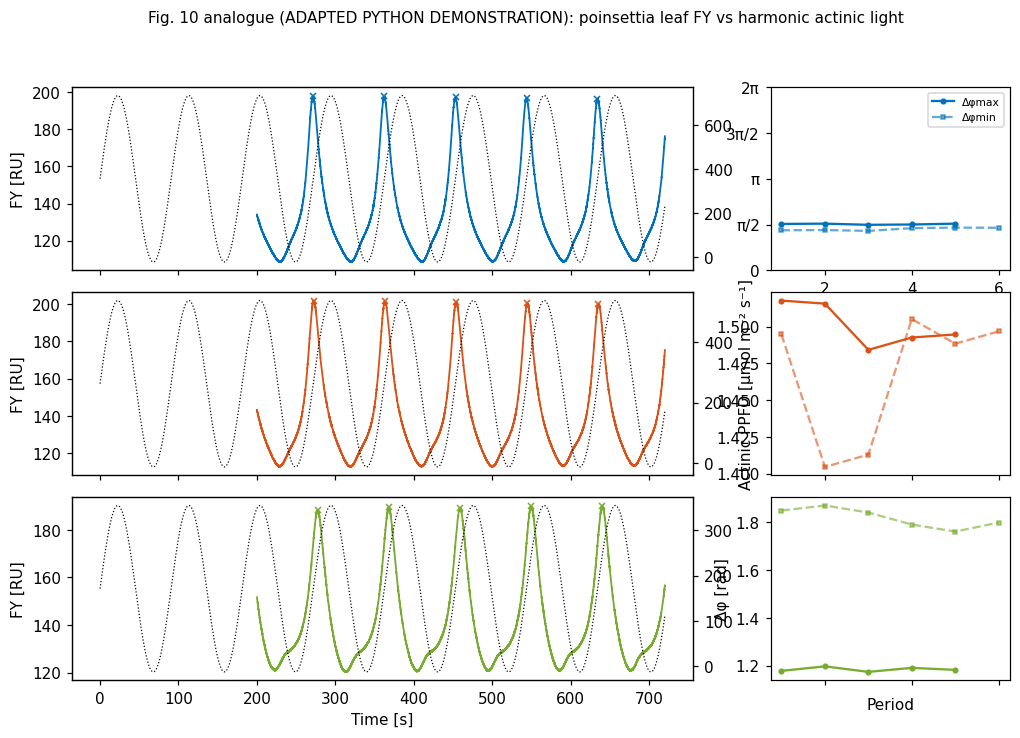

In [ ]:
PPFD = lambda i: round(amp_A(i) * 6.08 - 30.8 + amp_a(i) * 6.12 - 12.4)  # makeGraphs.m line 71
colors = ["#0072BD", "#D95319", "#77AC30"]
fig = plt.figure(figsize=(11, 7), dpi=110)
gs = fig.add_gridspec(3, 2, width_ratios=[2.6, 1], hspace=0.12, wspace=0.18)
for row, i in enumerate(mostCin):
    r, d = recs[i], analyses[i]
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(r["time"], r["measurementNI"], color=colors[row], lw=1.2,
            label=f"FY ({'High' if row==0 else 'Medium' if row==1 else 'Low'}, PPFD≈{PPFD(i)})")
    modelPPFD = (r["modelReal"] * 6.08 - 30.8 if amp_a(i) == 0 else
                 r["modelReal"] * 6.12 - 12.4 if amp_A(i) == 0 else
                 (r["modelReal"] * 6.08 - 30.8 + r["modelReal"] * 6.12 - 12.4) / 2)
    ax2 = ax.twinx()
    ax2.plot(r["Time"], modelPPFD, "k:", lw=0.8, label="Actinic PPFD")
    ax2.set_ylabel("Actinic PPFD [µmol m⁻² s⁻¹]" if row == 1 else "")
    ax.set_ylabel("FY [RU]")
    if row < 2: ax.set_xticklabels([])
    else: ax.set_xlabel("Time [s]")
    for pk in d["inMaxD"]:
        ax.plot(r["time"][pk], r["measurementNI"][pk], "x", color=colors[row], ms=4)
    sp = fig.add_subplot(gs[row, 1])
    sp.plot(np.arange(1, len(d["maxPdiff"]) + 1), d["maxPdiff"] * 2 * np.pi, "o-", ms=3,
            color=colors[row], label="Δφmax")
    sp.plot(np.arange(1, len(d["minPdiff"]) + 1), d["minPdiff"] * 2 * np.pi, "s--", ms=3,
            color=colors[row], alpha=0.6, label="Δφmin")
    if row == 0:
        sp.set_ylim(0, 2 * np.pi); sp.set_yticks(np.linspace(0, 2*np.pi, 5))
        sp.set_yticklabels(["0", "π/2", "π", "3π/2", "2π"])
        sp.legend(fontsize=7, loc="upper right")
    else: sp.set_xticklabels([])
    if row == 2: sp.set_xlabel("Period"); sp.set_ylabel("Δφ [rad]")
fig.suptitle("Fig. 10 analogue (ADAPTED PYTHON DEMONSTRATION): poinsettia leaf FY vs harmonic actinic light", fontsize=10)
fig.savefig("/content/fig10_intensity.png", bbox_inches="tight")
plt.show()

### Statistics table (matches the author's printed fprintf summary)
The author's script prints mean ± std of Δφmax·2π, Δφmin·2π and A_Pk-Pk per intensity
(makeGraphs.m lines 331–343). We tabulate the same quantities, plus the period count.
**統計量を表にまとめます**（著者の fprintf 出力と同じ量）。

In [ ]:
rows = []
for i in mostCin:
    d = analyses[i]
    rows.append({"intensity": "High" if i == mostCin[0] else "Medium" if i == mostCin[1] else "Low",
                 "a": amp_a(i), "A": amp_A(i), "PPFD≈": PPFD(i),
                 "periods": len(d["maxPdiff"]),
                 "Δφmax [rad] mean±std": f"{d['maxPdiff'].mean()*2*np.pi:.3f} ± {d['maxPdiff'].std()*2*np.pi:.3f}",
                 "Δφmin [rad] mean±std": f"{d['minPdiff'].mean()*2*np.pi:.3f} ± {d['minPdiff'].std()*2*np.pi:.3f}",
                 "A_Pk-Pk [RU] mean±std": f"{d['ampDiff'].mean():.2f} ± {d['ampDiff'].std():.2f}"})
stats10 = pd.DataFrame(rows)
print(stats10.to_string(index=False))
stats10.to_csv("/content/fig10_stats.csv", index=False)
print("saved /content/fig10_stats.csv")

intensity    a    A  PPFD≈  periods Δφmax [rad] mean±std Δφmin [rad] mean±std A_Pk-Pk [RU] mean±std
     High 30.0 32.0    335        5        1.586 ± 0.016        1.413 ± 0.045          88.59 ± 0.70
   Medium 45.0  0.0    232        5        1.501 ± 0.013        1.467 ± 0.042          88.14 ± 0.84
      Low 30.0  0.0    140        5        1.184 ± 0.008        1.818 ± 0.038          68.87 ± 0.59
saved /content/fig10_stats.csv


## Figure 11 — two simultaneously modulated lights vs the sum of individual responses
**Method mapping (makeGraphs.m lines ~1140–1250):** combined-light experiments are those with both
amplitudes non-zero (`bothAmplIn`); for the amplitude pair `a = uniqA`, `A = max(A)`, and each
variable-light frequency `uniqF` matched within 5%, the sum prediction is built exactly as the
author does: interpolate each single-light `measurement` onto the combined `Time` base, subtract
each experiment's DC level `s1H(end-1)`, sum, and add the combined experiment's DC level
(s1H is the author's harmonic-fit parameter vector; its next-to-last entry is the offset).
If the leaf response were linear, the measured combined FY would equal this sum; the paper's key
finding is that it does not.
**Fig. 11 を再現します**: 個別応答の和（補間+オフセット補正）と同時照射の実測を比較します。

In [ ]:
bothAmplIn = (a_arr != 0) & (A_arr != 0)
uniqA = np.unique(a_arr[bothAmplIn])
oneFreqAIn = oneFreqIn & (A_arr != 0)
k = 0                                   # author uses only the first amplitude pair (for k = 1 : 1)
amp = uniqA[k]
comb_exps = [i for i in range(n_exp) if a_arr[i] == amp and bothAmplIn[i]]
f0 = freq_f(comb_exps[0])
Amax = max(amp_A(i) for i in comb_exps)
# variable-light-only experiments whose F matches any combined experiment's F within 5%
sim = [i for i in range(n_exp) if oneFreqAIn[i] and
       any(abs(F_arr[i] - F_arr[c]) / F_arr[c] < 0.05 for c in comb_exps)]
uniqF = np.unique([F_arr[i] for i in sim])
print("uniqA =", uniqA, "| fixed-light f0 =", f0, "Hz | Amax =", Amax)
print("combined experiments:", [inv['name'][i] for i in comb_exps])
print("uniqF =", uniqF)

uniqA = [30.] | fixed-light f0 = 0.011038 Hz | Amax = 32.0
combined experiments: ['2023_12_16-20_06_14---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0111_0.011038-m10-s720.bin', '2023_12_16-20_33_35---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0125_0.012142-m10-s720.bin', '2023_12_16-21_00_46---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011536-A32-O3-P0_0.0-F0.0098_0.0096137-m10-s720.bin', '2023_12_16-21_27_57---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011038-A32-O3-P0_0.0-F0.0153_0.015453-m10-s720.bin', '2023_12_16-21_55_11---poinsettia-both----a30-o3-p0_0.0-f0.0111_0.011353-A32-O3-P0_0.0-F0.00713_0.0070958-m10-s720.bin']
uniqF = [0.0070958 0.0096137 0.011038  0.012418  0.014901 ]


### Build the sum prediction and render the Figure 11 analogue
For every `uniqF`: FY fix (light 1 alone), FY var (light 2 alone), their interpolated sum
`FY fix+var`, and the measured combined FY. The actinic PPFD model of each experiment is overlaid on
a twin axis. Panels are ordered by increasing variable-light frequency.
**各周波数について「和の予測」と「実測の同時照射応答」を描画します。**

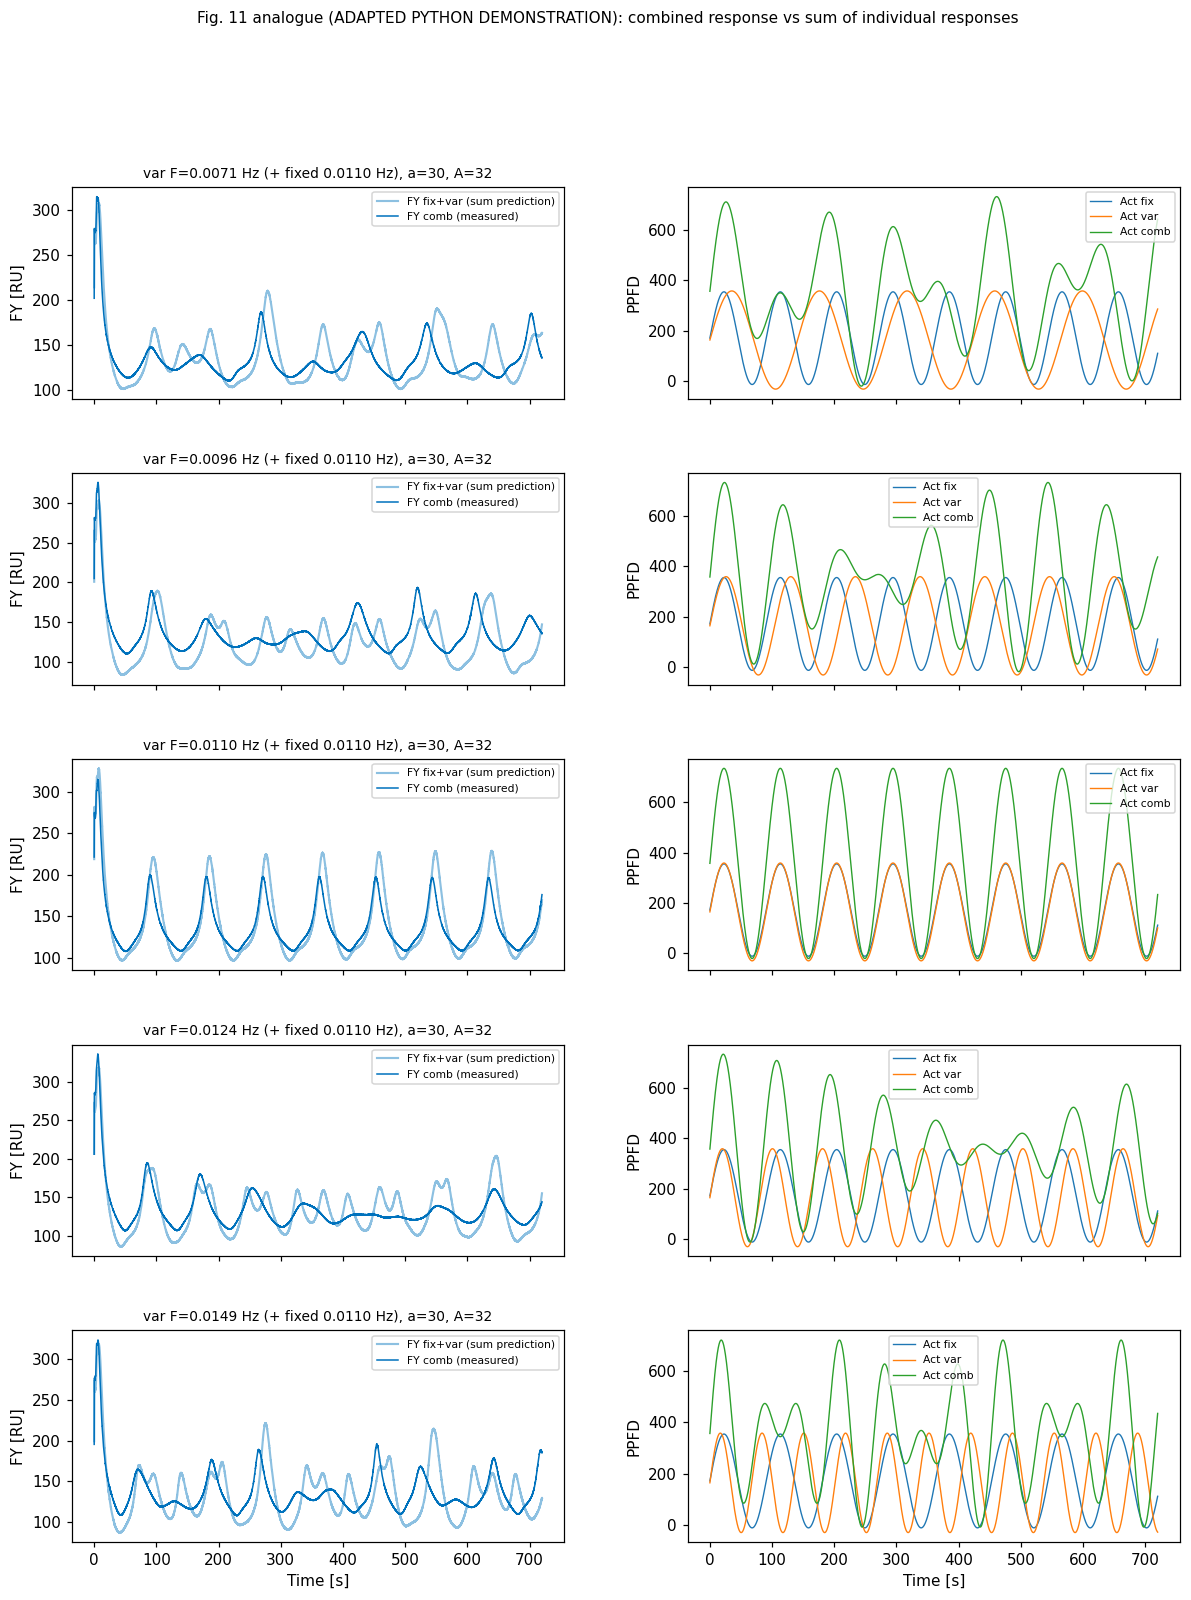

In [ ]:
fig = plt.figure(figsize=(13, 3.2 * len(uniqF)), dpi=110)
gs = fig.add_gridspec(len(uniqF), 2, hspace=0.35, wspace=0.25)
fig11_data = {}
for j, Ft in enumerate(uniqF):
    i1 = [i for i in range(n_exp) if freq_f(i) == f0 and a_arr[i] == amp and A_arr[i] == 0][0]
    i2 = [i for i in range(n_exp) if abs(F_arr[i] - Ft) / Ft < 0.05 and a_arr[i] == 0 and A_arr[i] == Amax][0]
    i3 = [i for i in range(n_exp) if abs(F_arr[i] - Ft) / Ft < 0.05 and a_arr[i] == amp
          and A_arr[i] == Amax and (freq_f(i) - f0) / f0 < 0.05][0]
    r1, r2, r3 = recs[i1], recs[i2], recs[i3]
    meas1 = np.interp(r3["Time"], r1["Time"], r1["measurement"]) - r1["s1H"].ravel()[-2]
    meas2 = np.interp(r3["Time"], r2["Time"], r2["measurement"]) - r2["s1H"].ravel()[-2]
    sumFY = meas1 + meas2 + r3["s1H"].ravel()[-2]
    fig11_data[Ft] = dict(i1=i1, i2=i2, i3=i3, sumFY=sumFY,
                          comb=r3["measurement"], Time=r3["Time"])
    ax = fig.add_subplot(gs[j, 0])
    sum_col = tuple(0.55 + 0.45 * c for c in mpl.colors.to_rgb(colors[0]))
    ax.plot(r3["Time"], sumFY, color=sum_col,
            lw=1.4, label="FY fix+var (sum prediction)")
    ax.plot(r3["Time"], r3["measurement"], color=colors[0], lw=1.0, label="FY comb (measured)")
    ax.set_ylabel("FY [RU]"); ax.legend(fontsize=7, loc="upper right")
    ax.set_title(f"var F={Ft:.4f} Hz (+ fixed {f0:.4f} Hz), a={amp:.0f}, A={Amax:.0f}", fontsize=9)
    if j == len(uniqF) - 1: ax.set_xlabel("Time [s]")
    else: ax.set_xticklabels([])
    ax2 = fig.add_subplot(gs[j, 1])
    for ii, lab in ((i1, "Act fix"), (i2, "Act var"), (i3, "Act comb")):
        rr = recs[ii]
        pp = (rr["modelReal"] * 6.08 - 30.8 if amp_a(ii) == 0 else
              rr["modelReal"] * 6.12 - 12.4 if amp_A(ii) == 0 else
              (rr["modelReal"] * 6.08 - 30.8 + rr["modelReal"] * 6.12 - 12.4) / 2)
        ax2.plot(rr["Time"], pp, lw=0.9, label=lab)
    ax2.legend(fontsize=7); ax2.set_ylabel("PPFD")
    if j == len(uniqF) - 1: ax2.set_xlabel("Time [s]")
    else: ax2.set_xticklabels([])
fig.suptitle("Fig. 11 analogue (ADAPTED PYTHON DEMONSTRATION): combined response vs sum of individual responses", fontsize=10)
fig.savefig("/content/fig11_mixFreq.png", bbox_inches="tight")
plt.show()

### Quantify the non-additivity
Compare the measured combined FY with the sum prediction per frequency: relative RMS difference
normalized by the peak-to-peak range of the measured combined signal, plus the maximum absolute
difference. If responses were additive both would coincide; the paper's conclusion is that they do
not. These metrics are computed for this notebook (they are not printed in the paper, which shows
the comparison graphically).
**非加法性を定量化します**（RMS 差 / 実測 ptp）。

In [ ]:
rows = []
for Ft, d in sorted(fig11_data.items()):
    resid = d["comb"] - d["sumFY"]
    valid = np.isfinite(resid)
    rows.append({"var F [Hz]": round(Ft, 4),
                 "measured ptp [RU]": np.ptp(d["comb"][valid]),
                 "rel RMS diff": np.sqrt(np.mean(resid[valid] ** 2)) / np.ptp(d["comb"][valid]),
                 "max |diff| [RU]": np.abs(resid[valid]).max()})
stats11 = pd.DataFrame(rows)
print(stats11.to_string(index=False))
stats11.to_csv("/content/fig11_stats.csv", index=False)
print("saved /content/fig11_stats.csv")

 var F [Hz]  measured ptp [RU]  rel RMS diff  max |diff| [RU]
     0.0071         204.590341      0.111963        62.954157
     0.0096         215.748268      0.130438        71.125480
     0.0110         206.837569      0.091811        57.012921
     0.0124         230.105167      0.077459        45.512506
     0.0149         215.644238      0.131179        83.089161
saved /content/fig11_stats.csv


## Comparison with the authors' published figures (reference, CC BY)
The archive contains the authors' own outputs `intensity.eps` and `mixFreq1.eps`. We render them
with ghostscript and display them side-by-side with our results. They are **author source material
(clearly labeled)** used for validation — not outputs of this notebook's code.
**著者の参考図（CC BY）をレンダリングし、比較表示します。**

author_intensity.png — author's reference figure from Figures_10_11_pointsettia.zip (CC BY)


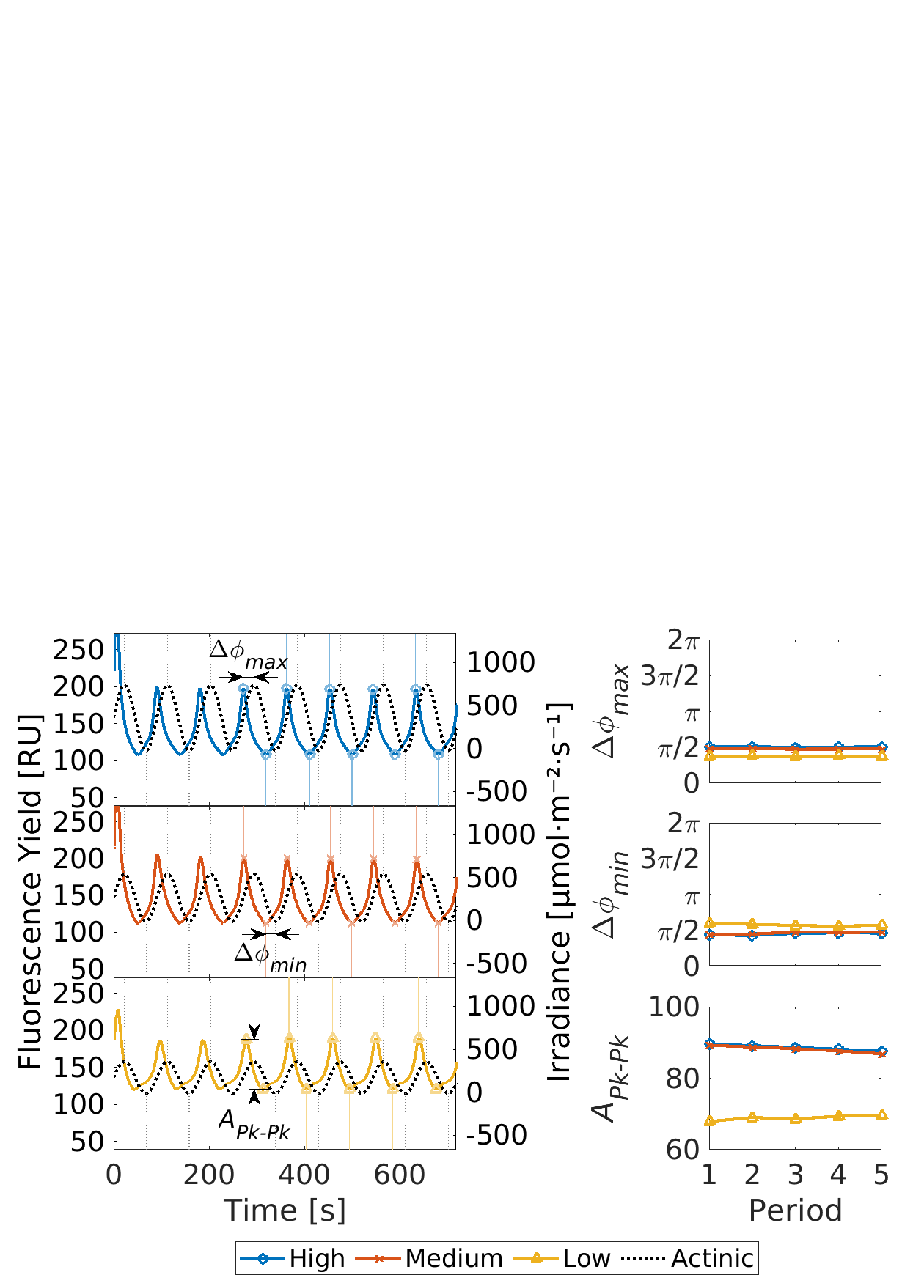

author_mixFreq1.png — author's reference figure from Figures_10_11_pointsettia.zip (CC BY)


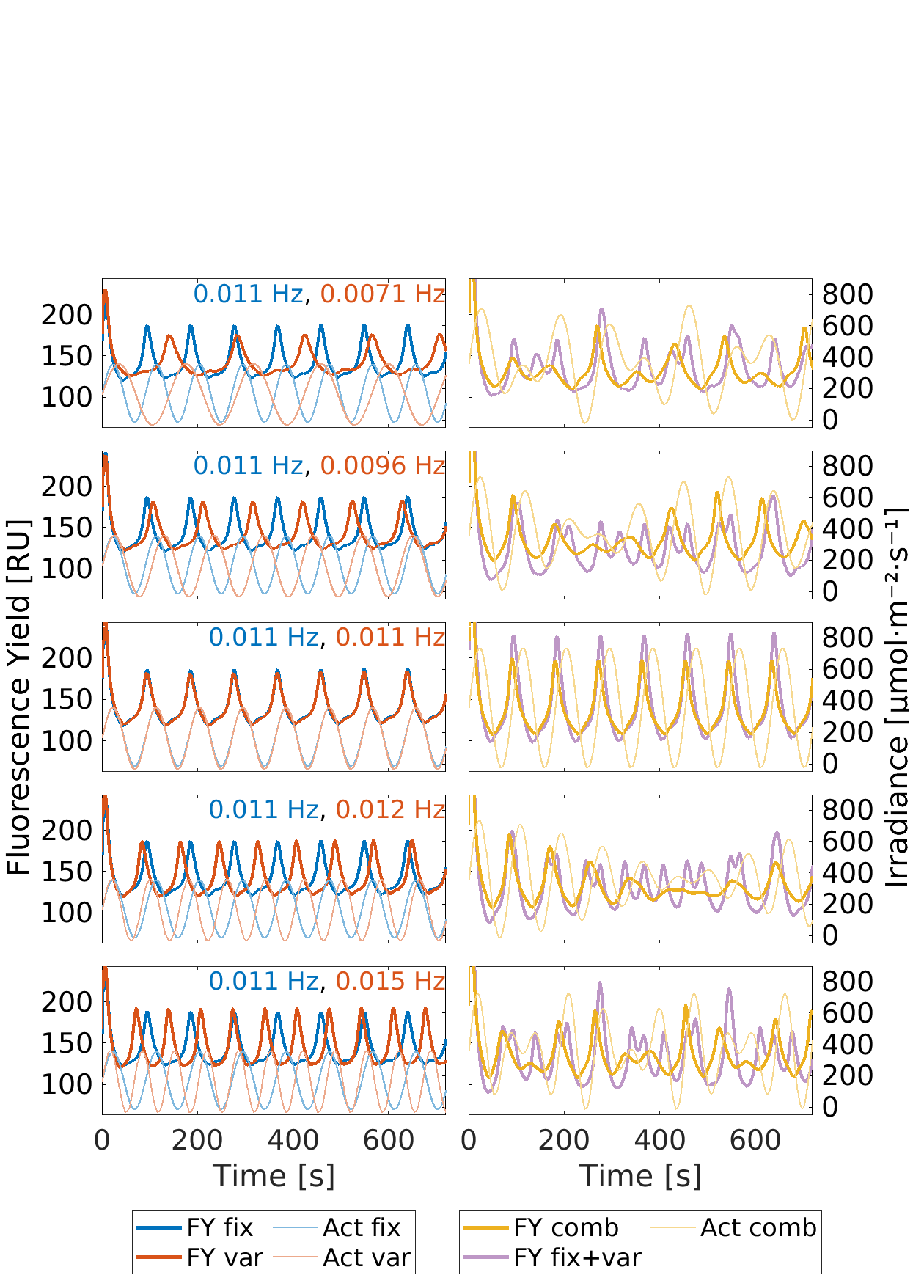

In [ ]:
import subprocess
for eps, png in (("intensity.eps", "author_intensity.png"),
                 ("mixFreq1.eps", "author_mixFreq1.png")):
    subprocess.run(["gs", "-dSAFER", "-dBATCH", "-dNOPAUSE", "-sDEVICE=png16m",
                    "-r110", f"-sOutputFile=/content/{png}", f"{ARCH}/{eps}"],
                   check=True, capture_output=True)
from IPython.display import display, Image
for png in ("author_intensity.png", "author_mixFreq1.png"):
    print(png, "— author's reference figure from Figures_10_11_pointsettia.zip (CC BY)")
    display(Image(filename=f"/content/{png}"))

## Interpretation and limitations
- **What this shows:** using the authors' own processed data, the measured fluorescence-yield
  response to two simultaneously modulated harmonic lights (Fig. 11 analogue) deviates from the sum
  of the individual responses — the paper's central non-additivity finding
  (bioRxiv v1, §Leaf experiment: two-light superposition). The Fig. 10 analogue shows the
  amplitude-dependent response shape with phase delays Δφmax/Δφmin and A_Pk-Pk per period.
- **What this does NOT show:** this is a one-dataset, partial demonstration. It does not validate
  the instrument, the 23-experiment study, calibration figures 3–9, or any dataset-level claims.
- **Adaptations:** Python re-implementation of the numerical core of `makeGraphs.m` (the author
  script itself cannot run under Octave); plotting style deliberately approximates but does not
  clone the author's MATLAB layout; non-additivity metrics were computed for this notebook and are
  not published in the paper.
- **Validation record:** executed top-to-bottom on a fresh Colab CPU runtime (see the archived
  execution output); results compared qualitatively against the authors' reference EPS figures.
- **参考:** 実行環境は CPU。自由枠では時間・可用性が異なる場合があります。

**References**
1. Jokinen et al., bioRxiv 2024.04.18.589113v1. https://doi.org/10.1101/2024.04.18.589113
2. KORDS/Figshare record 25599564.v1 (`Figures_10_11_pointsettia.zip`, CC BY) — data and makeGraphs.m.
3. KORDS/Figshare record 25602054.v1 (`harmonizer.code.zip`, CC BY) — instrument control code.
4. PhenoPaper investigation p-445c34da82cdb01531f293f0701af907-20260929T110455Z-2544626 (prior
   research guidance, unverified AI findings).